```Decision Tree Regression with the Boston Housing Dataset```

In [1]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

# Load the California Housing dataset
california = fetch_california_housing()
X = pd.DataFrame(california.data, columns=california.feature_names)
y = california.target

# Display basic information about the dataset
print(X.info())
print(X.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB
None
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.4

In [2]:
from sklearn.model_selection import train_test_split

# Split the data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
from sklearn.tree import DecisionTreeRegressor

# Initialize the Decision Tree Regressor
dt_regressor = DecisionTreeRegressor(max_depth=5, random_state=42)

# Train the model
dt_regressor.fit(X_train, y_train)


DecisionTreeRegressor(max_depth=5, random_state=42)

max_depth: Limits the depth of the tree to prevent overfitting.

random_state: Ensures reproducibility of results.

In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict on the test set
y_pred = dt_regressor.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

Mean Absolute Error (MAE): 0.52
Mean Squared Error (MSE): 0.52
Root Mean Squared Error (RMSE): 0.72
R² Score: 0.60


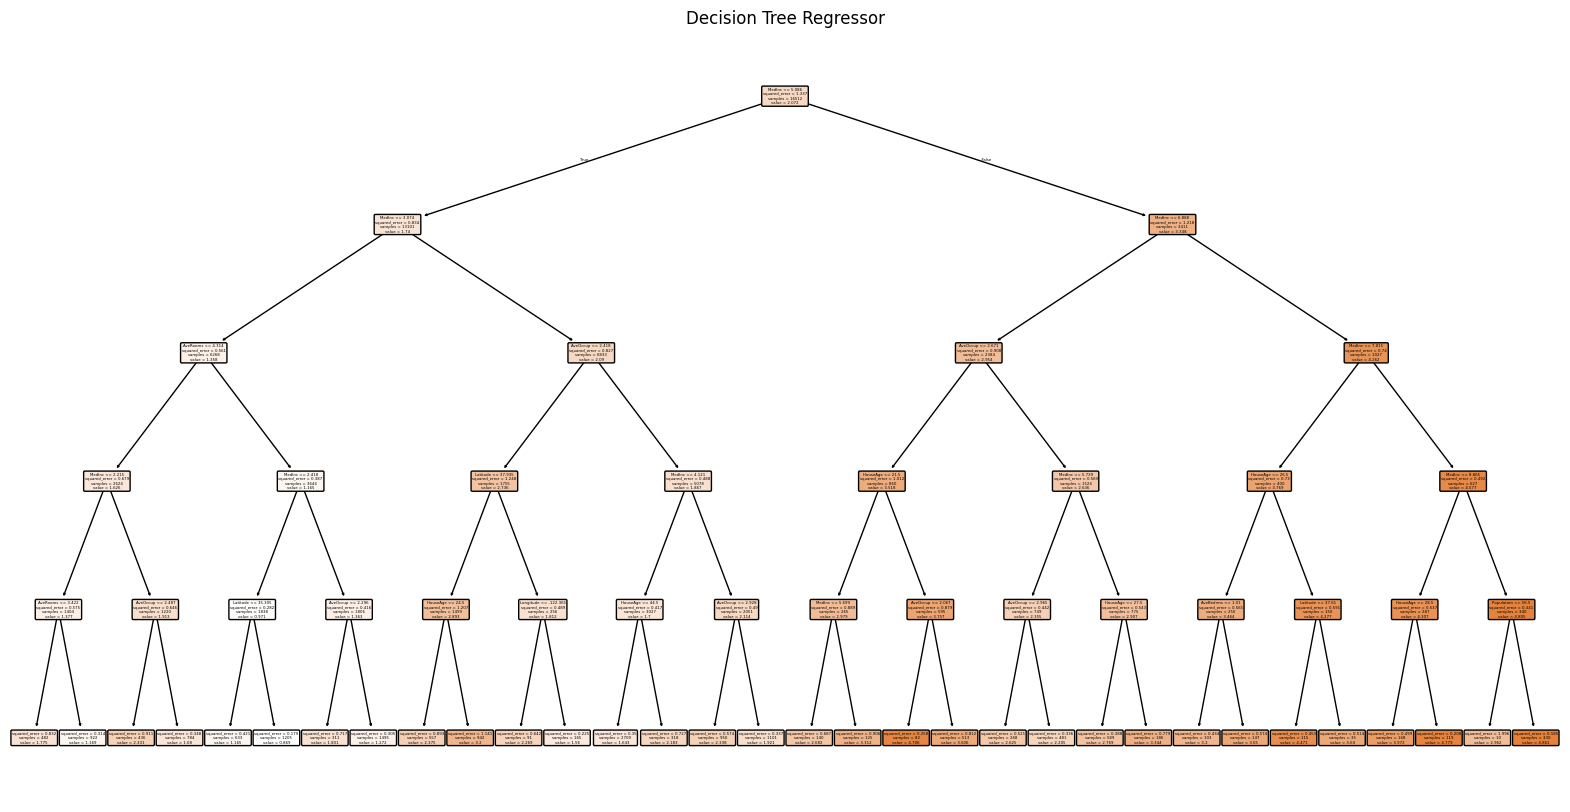

In [5]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Plot the decision tree
plt.figure(figsize=(20,10))
plot_tree(dt_regressor, feature_names=california.feature_names, filled=True, rounded=True)
plt.title("Decision Tree Regressor")
plt.show()

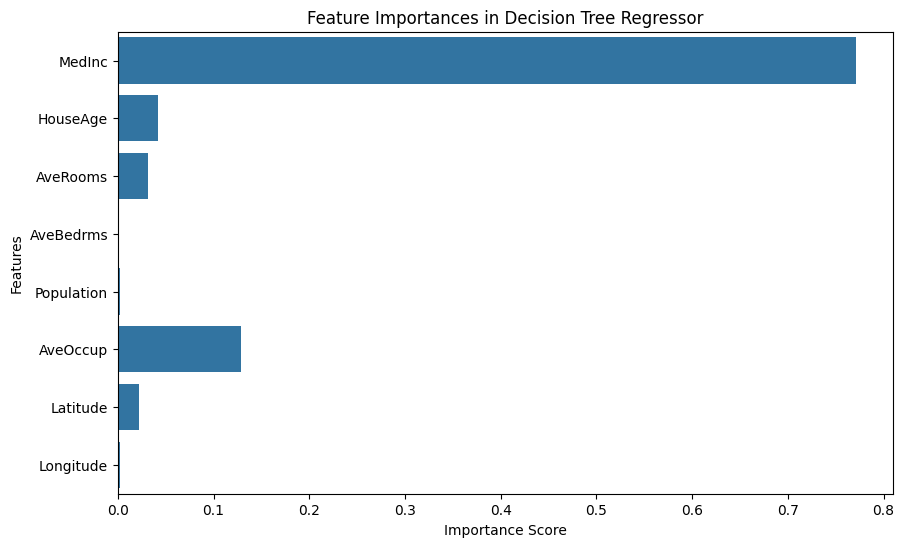

In [6]:
import seaborn as sns

# Get feature importances
feature_importances = pd.Series(dt_regressor.feature_importances_, index=california.feature_names)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_importances.index)
plt.title("Feature Importances in Decision Tree Regressor")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

Feature Importance: Identifies which features have the most influence on predictions.

```Decision Tree Classification with the Iris Dataset```

In [7]:
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# Display basic information about the dataset
print(X.info())
print(X.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB
None
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000 

In [8]:
# Split the data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)

# Train the model
dt_classifier.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

criterion: Determines the function to measure the quality of a split ('gini' for Gini Impurity, 'entropy' for Information Gain).

max_depth: Limits the depth of the tree to prevent overfitting.

In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predict on the test set
y_pred = dt_classifier.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Display classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Display confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 1.00
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


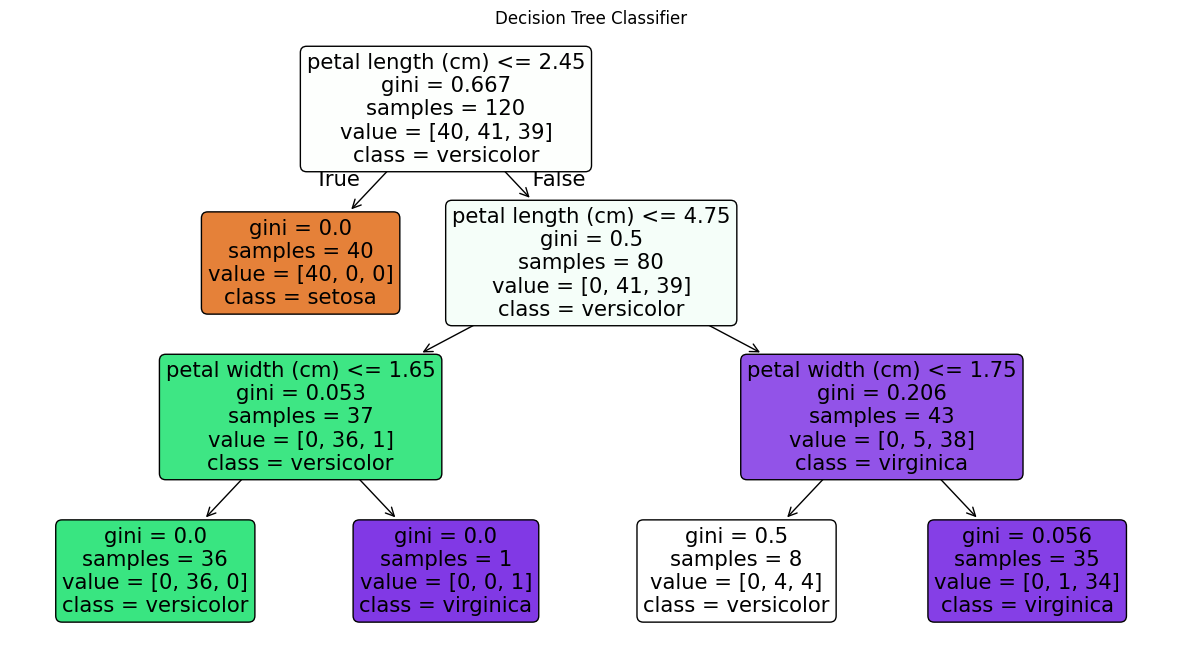

In [11]:
# Plot the decision tree
plt.figure(figsize=(15,8))
plot_tree(dt_classifier, feature_names=iris.feature_names, class_names=iris.target_names, filled=True, rounded=True)
plt.title("Decision Tree Classifier")
plt.show()

```Visualize Decision Boundaries```

In [14]:
import numpy as np
from matplotlib.colors import ListedColormap

# Select two features for visualization
X_vis = X_train.iloc[:, [0, 2]].values
y_vis = y_train

# Train classifier with selected features
dt_classifier_vis = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_classifier_vis.fit(X_vis, y_vis)
import numpy as np
from matplotlib.colors import ListedColormap

# Select two features for visualization
X_vis = X_train.iloc[:, [0, 2]].values
y_vis = y_train

# Train classifier with selected features
dt_classifier_vis = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_classifier_vis.fit(X_vis, y_vis)

# Plot decision boundaries
x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1